# Analisis espacial: Conexion Social vs. pobreza multidimensional (EMB)

**Equipo Conexion Social - Bogota me conecta | Bogota Datajam 2026**

## Objetivo

Este notebook responde la pregunta de analisis del equipo:

> ¿Las instalaciones del programa Conexion Social estan llegando efectivamente a las
> zonas de Bogota con mayores niveles de pobreza multidimensional?

Se compara el numero de **hogares instalados** por el programa Conexion Social
(fuente interna SDIS, `Perfiles_CS.xlsx`) contra el **Indice de Pobreza
Multidimensional (IPM)** estimado con la **Encuesta Multiproposito de Bogota (EMB) 2021**,
desagregando por:

1. **Localidad** (20 localidades urbanas) - desagregacion robusta, 1 a 1 con la EMB.
2. **UPZ** (Unidad de Planeamiento Zonal) - desagregacion intermedia. La EMB publica sus
   estimaciones por **grupos de UPZ** (varias UPZ pequeñas agregadas por tamaño de muestra),
   por lo que se construye una tabla de correspondencia UPZ individual -> grupo de UPZ.
3. **Sector catastral** - solo de forma descriptiva para las instalaciones de Conexion
   Social, ya que la EMB **no tiene tamaño de muestra suficiente** para estimar pobreza a
   ese nivel de detalle (ver nota de limitacion en la seccion 6).

> **Nota sobre SIMAT:** el cruce con matricula por establecimiento educativo (SIMAT) se
> deja pendiente a peticion del equipo. La seccion 8 deja preparada la estructura para
> integrarlo cuando se disponga del archivo.

## Fuentes de datos

| Fuente | Archivo | Nivel | Sensibilidad |
|---|---|---|---|
| Instalaciones Conexion Social | `Perfiles_CS.xlsx` | Hogar (con direccion y coordenadas) | **Sensible** - no se sube a GitHub |
| Encuesta Multiproposito 2021 | `em2021.csv` | Persona/hogar (microdato) | **Sensible** - no se sube a GitHub |
| Variables adicionales EMB (IPM) | `20240430_variables_adicionales_2021.csv` | Hogar/persona | **Sensible** - no se sube a GitHub |
| Limites de Localidad | Datos Abiertos Bogota / IDECA (ArcGIS REST) | Poligono | Publica |
| Limites de UPZ | Datos Abiertos Bogota / IDECA (ArcGIS REST) | Poligono | Publica |
| Limites de Sector Catastral | Datos Abiertos Bogota / IDECA (ArcGIS REST) | Poligono | Publica |

Los archivos originales con datos personales (direcciones, coordenadas exactas de
hogares, microdatos EMB) **permanecen solo en este computador** (ver `.gitignore`). Al
repositorio de GitHub solo se suben este notebook y los resultados **agregados** por
localidad / UPZ / sector catastral (sin informacion individual).


## 1. Configuracion

In [1]:
import json
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from shapely.geometry import Point

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110


def normalizar(texto: str) -> str:
    # Normaliza nombres geograficos para poder cruzar entre fuentes que usan
    # mayusculas/tildes distintas (ej. "Ciudad Bolivar" vs "CIUDAD BOLIVAR").
    texto = str(texto).upper().strip()
    texto = "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")
    return texto


# Rutas del proyecto (este notebook vive en DataJam/notebooks/)
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR
GEO_DIR = BASE_DIR / "data" / "geo"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUT_TABLES = BASE_DIR / "outputs" / "tables"
OUT_FIGS = BASE_DIR / "outputs" / "figures"

for d in (GEO_DIR, PROCESSED_DIR, OUT_TABLES, OUT_FIGS):
    d.mkdir(parents=True, exist_ok=True)

print("Carpeta base del proyecto:", BASE_DIR)


Carpeta base del proyecto: C:\Users\Lenovo\Documents\JSEH\SDIS\DataJam


## 2. Poligonos geograficos oficiales (localidad, UPZ, sector catastral)

Se descargan de los servicios geograficos publicos de Catastro Bogota / IDECA
(`serviciosgis.catastrobogota.gov.co`), publicados tambien en el Portal de Datos
Abiertos de Bogota (https://datosabiertos.bogota.gov.co). Se guardan en
`data/geo/*.geojson` para no depender de internet en corridas futuras y para poder
versionar estos limites (son informacion publica, no sensible) en el repositorio.

Nota cartografica: Sumapaz (la unica localidad rural de Bogota) se excluye de los
**mapas** por su enorme extension relativa frente a las 19 localidades urbanas, lo que
aplastaria visualmente el resto de la ciudad. Las **tablas** si conservan a Sumapaz.


In [2]:
ARCGIS_LAYERS = {
    "localidad": "https://serviciosgis.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/localidad/MapServer/0",
    "upz": "https://serviciosgis.catastrobogota.gov.co/arcgis/rest/services/ordenamientoterritorial/unidadplaneamientozonal/MapServer/0",
    "sector_catastral": "https://serviciosgis.catastrobogota.gov.co/arcgis/rest/services/catastro/sectorcatastral/MapServer/0",
}


def descargar_capa_arcgis(url_layer: str, page_size: int = 1000) -> gpd.GeoDataFrame:
    # Descarga todos los registros de una capa ArcGIS REST como GeoDataFrame (EPSG:4326)
    features = []
    offset = 0
    while True:
        params = {
            "where": "1=1",
            "outFields": "*",
            "f": "geojson",
            "outSR": 4326,
            "resultOffset": offset,
            "resultRecordCount": page_size,
        }
        r = requests.get(f"{url_layer}/query", params=params, timeout=60)
        r.raise_for_status()
        chunk = r.json().get("features", [])
        if not chunk:
            break
        features.extend(chunk)
        if len(chunk) < page_size:
            break
        offset += page_size
    return gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")


def cargar_capa(nombre: str) -> gpd.GeoDataFrame:
    ruta = GEO_DIR / f"{nombre}.geojson"
    if ruta.exists():
        return gpd.read_file(ruta)
    gdf = descargar_capa_arcgis(ARCGIS_LAYERS[nombre])
    gdf.to_file(ruta, driver="GeoJSON")
    return gdf


gdf_localidad = cargar_capa("localidad")
gdf_upz = cargar_capa("upz")
gdf_sector = cargar_capa("sector_catastral")

# Llave normalizada para poder cruzar contra otras fuentes (EMB, Perfiles_CS)
# que no necesariamente usan las mismas mayusculas/tildes.
gdf_localidad["LOC_KEY"] = gdf_localidad["LOCNOMBRE"].apply(normalizar)

# Sumapaz es la unica localidad rural de Bogota: su area es varias veces mayor que
# las 19 localidades urbanas juntas y el programa Conexion Social (fibra optica
# urbana) practicamente no tiene presencia alli. Se excluye SOLO de los mapas para
# que la variacion en la zona urbana sea visible; las tablas si la conservan.
gdf_localidad_urbano = gdf_localidad[gdf_localidad["LOC_KEY"] != "SUMAPAZ"].copy()
area_urbana_union = gdf_localidad_urbano.union_all()

print("Localidades:", len(gdf_localidad))
print("UPZ:", len(gdf_upz))
print("Sectores catastrales:", len(gdf_sector))
gdf_localidad.head(3)


Localidades: 20
UPZ: 112
Sectores catastrales: 1230


,OBJECTID,LOCNOMBRE,LOCAADMINI,LOCAREA,LOCCODIGO,SHAPE.AREA,SHAPE.LEN,geometry,LOC_KEY
0,1,ANTONIO NARIÑO,Acuerdo 117 de 2003,4.879543e+06,15,0.000397,0.108973,"POLYGON ((-74.13075 4.59335, -74.13075 4.59335...",ANTONIO NARINO
1,2,TUNJUELITO,Acuerdo 117 de 2003,9.910940e+06,06,0.000807,0.210542,"POLYGON ((-74.13777 4.59489, -74.14043 4.59536...",TUNJUELITO
2,3,RAFAEL URIBE URIBE,Acuerdo 117 de 2003,1.383408e+07,18,0.001126,0.174513,"POLYGON ((-74.12803 4.59254, -74.12829 4.59265...",RAFAEL URIBE URIBE


## 3. Hogares instalados de Conexion Social (`Perfiles_CS.xlsx`)

El archivo trae coordenadas (`COORD_X_AUTO_REC` = latitud, `COORD_Y_AUTO_REC` = longitud,
WGS84) y ya viene con `UPZNombre` y `SCaNombre` (sector catastral), pero **no** trae
`Localidad`. Se obtiene por union espacial (punto dentro de poligono) contra
`gdf_localidad`.


In [3]:
df_cs = pd.read_excel(DATA_DIR / "Perfiles_CS.xlsx")
print("Hogares instalados Conexion Social:", len(df_cs))

# OJO: no se muestra el detalle de filas individuales (trae DIRECCION y coordenadas
# exactas por hogar). Este notebook se sube a un repositorio publico, asi que solo se
# despliegan columnas no identificables a modo de vista previa de la estructura.
df_cs[["ESTRATO", "SCaNombre", "UPZNombre", "CLASIFICACION_DIC", "No_Integrantes"]].head(3)


Hogares instalados Conexion Social: 15465


,ESTRATO,SCaNombre,UPZNombre,CLASIFICACION_DIC,No_Integrantes
0,2,BOCHICA,MINUTO DE DIOS,B07,5
1,2,BOCHICA,MINUTO DE DIOS,C06,7
2,2,BOCHICA,MINUTO DE DIOS,C04,4


In [4]:
# Punto (lon, lat) -> geometria. OJO: COORD_X_AUTO_REC es latitud y COORD_Y_AUTO_REC es longitud.
geometry = [Point(lon, lat) for lat, lon in zip(df_cs["COORD_X_AUTO_REC"], df_cs["COORD_Y_AUTO_REC"])]
gdf_cs = gpd.GeoDataFrame(df_cs.copy(), geometry=geometry, crs="EPSG:4326")

# Union espacial contra localidades
gdf_cs = gpd.sjoin(
    gdf_cs, gdf_localidad[["LOCNOMBRE", "LOCCODIGO", "LOC_KEY", "geometry"]],
    how="left", predicate="within",
).drop(columns="index_right")

# Algunos puntos pueden caer justo sobre un limite/afuera por precision de coordenadas:
# se recuperan con el poligono mas cercano.
sin_localidad = gdf_cs["LOCNOMBRE"].isna()
if sin_localidad.any():
    cercano = gpd.sjoin_nearest(
        gdf_cs.loc[sin_localidad, ["geometry"]],
        gdf_localidad[["LOCNOMBRE", "LOCCODIGO", "LOC_KEY", "geometry"]],
        how="left",
    )
    gdf_cs.loc[sin_localidad, "LOCNOMBRE"] = cercano["LOCNOMBRE"].values
    gdf_cs.loc[sin_localidad, "LOCCODIGO"] = cercano["LOCCODIGO"].values
    gdf_cs.loc[sin_localidad, "LOC_KEY"] = cercano["LOC_KEY"].values

print(f"Hogares sin localidad tras union espacial directa: {sin_localidad.sum()} (recuperados por vecino mas cercano)")
gdf_cs["LOCNOMBRE"].value_counts()


Hogares sin localidad tras union espacial directa: 0 (recuperados por vecino mas cercano)


LOCNOMBRE
BOSA                  3414
KENNEDY               2575
SUBA                  2030
SAN CRISTOBAL         1975
RAFAEL URIBE URIBE    1246
CIUDAD BOLIVAR        1216
ENGATIVA              1064
TUNJUELITO             787
SANTA FE               484
USAQUEN                231
FONTIBON               167
LOS MARTIRES            58
CANDELARIA              58
ANTONIO NARIÑO          54
CHAPINERO               52
PUENTE ARANDA           27
USME                    24
BARRIOS UNIDOS           3
Name: count, dtype: int64

## 4. Pobreza multidimensional (EMB 2021)

`em2021.csv` es un archivo ancho (1 fila por persona, ~1550 columnas, codificacion
`latin-1`) que junta los modulos de vivienda/hogar/persona/ingresos de la encuesta.
`20240430_variables_adicionales_2021.csv` trae variables derivadas ya calculadas,
entre ellas `N_pobre_ipm` (hogar pobre por IPM = 1/0). Se usa el motor `pyarrow` de
pandas por la robustez y velocidad frente a un archivo de ~1.2 GB.

Metodologia de agregacion: el IPM se mide a nivel de **hogar**, por lo que se
deduplica a nivel de `DIRECTORIO_HOG` y se pondera con el factor de expansion
`FEX_C` (cada hogar de la muestra representa `FEX_C` hogares de la poblacion) para
obtener una tasa de pobreza representativa de la ciudad, no solo de la muestra.


In [5]:
COLS_GEO = ["DIRECTORIO", "DIRECTORIO_HOG", "COD_LOCALIDAD", "NOMBRE_LOCALIDAD",
            "COD_UPZ_GRUPO", "NOMBRE_UPZ_GRUPO", "ESTRATO2021", "FEX_C"]

cache_geo = PROCESSED_DIR / "em2021_geo.parquet"
if cache_geo.exists():
    em_geo = pd.read_parquet(cache_geo)
else:
    em_geo = pd.read_csv(DATA_DIR / "em2021.csv", encoding="latin1",
                          usecols=COLS_GEO, engine="pyarrow")
    em_geo.to_parquet(cache_geo)

em_geo_hog = em_geo.drop_duplicates("DIRECTORIO_HOG")
print("Hogares unicos en la EMB 2021:", len(em_geo_hog))
em_geo_hog.head(3)


Hogares unicos en la EMB 2021: 107119


,DIRECTORIO,DIRECTORIO_HOG,COD_LOCALIDAD,NOMBRE_LOCALIDAD,COD_UPZ_GRUPO,NOMBRE_UPZ_GRUPO,ESTRATO2021,FEX_C
0,166238,1662381,2.0,Chapinero,NaN,NaN,11001202,1.698492
2,220102,2201021,19.0,Ciudad Bolívar,NaN,NaN,11001219,6.744412
6,220385,2203851,20.0,Sumapaz,NaN,NaN,11001220,1.804632


In [6]:
adicionales = pd.read_csv(
    DATA_DIR / "20240430_variables_adicionales_2021.csv", encoding="latin1",
    usecols=["directorio_hog", "N_pobre_ipm"],
).drop_duplicates("directorio_hog")

hogares_ipm = em_geo_hog.merge(
    adicionales, left_on="DIRECTORIO_HOG", right_on="directorio_hog", how="left",
)

sin_ipm = hogares_ipm["N_pobre_ipm"].isna().sum()
print(f"Hogares EMB sin dato de IPM tras el cruce: {sin_ipm} de {len(hogares_ipm)}")
hogares_ipm = hogares_ipm.dropna(subset=["N_pobre_ipm"])
hogares_ipm.to_parquet(PROCESSED_DIR / "hogares_ipm.parquet")
hogares_ipm[["NOMBRE_LOCALIDAD", "NOMBRE_UPZ_GRUPO", "FEX_C", "N_pobre_ipm"]].head(3)


Hogares EMB sin dato de IPM tras el cruce: 0 de 107119


,NOMBRE_LOCALIDAD,NOMBRE_UPZ_GRUPO,FEX_C,N_pobre_ipm
0,Chapinero,NaN,1.698492,1
1,Ciudad Bolívar,NaN,6.744412,0
2,Sumapaz,NaN,1.804632,0


In [7]:
def tasa_ipm_ponderada(g: pd.DataFrame) -> float:
    return float((g["N_pobre_ipm"] * g["FEX_C"]).sum() / g["FEX_C"].sum() * 100)


ipm_localidad = (
    hogares_ipm.groupby("NOMBRE_LOCALIDAD")
    .apply(tasa_ipm_ponderada, include_groups=False)
    .rename("pct_pobreza_ipm")
    .reset_index()
)
hogares_totales_localidad = (
    hogares_ipm.groupby("NOMBRE_LOCALIDAD")["FEX_C"].sum()
    .rename("hogares_totales_estimados_emb")
    .reset_index()
)
ipm_localidad = ipm_localidad.merge(hogares_totales_localidad, on="NOMBRE_LOCALIDAD")
ipm_localidad["LOC_KEY"] = ipm_localidad["NOMBRE_LOCALIDAD"].apply(normalizar)
ipm_localidad = ipm_localidad.sort_values("pct_pobreza_ipm", ascending=False)
ipm_localidad


,NOMBRE_LOCALIDAD,pct_pobreza_ipm,hogares_totales_estimados_emb,LOC_KEY
15,Sumapaz,15.580286,1135.113780,SUMAPAZ
19,Usme,10.226706,128688.921145,USME
4,Ciudad Bolívar,8.576726,208702.085748,CIUDAD BOLIVAR
13,Santa Fe,7.991648,39064.354319,SANTA FE
11,Rafael Uribe Uribe,6.667842,136687.354445,RAFAEL URIBE URIBE
2,Bosa,6.489109,233692.505621,BOSA
12,San Cristóbal,5.036779,135671.094960,SAN CRISTOBAL
9,Los Mártires,5.002996,33136.594637,LOS MARTIRES
8,La Candelaria,4.262378,7603.195214,LA CANDELARIA
17,Tunjuelito,3.845420,70431.856300,TUNJUELITO


### 4.1 Correspondencia UPZ individual -> grupo de UPZ de la EMB

La EMB no siempre publica cada UPZ por separado: cuando una UPZ es muy pequeña, la
agrupa con vecinas (ej. `"BARRIOS UNIDOS: Parque Salitre + Doce de Octubre"`). Como
`Perfiles_CS.xlsx` trae la UPZ individual (`UPZNombre`), se construye una tabla de
correspondencia automatica a partir de los nombres de `NOMBRE_UPZ_GRUPO`, tal como lo
identifica la nota tecnica del equipo: *"los codigos de UPZ y localidad difieren en
formato y nomenclatura entre entidades, lo que obliga a procesos manuales de
armonizacion previos al cruce"*.


In [8]:
grupos_upz = hogares_ipm["NOMBRE_UPZ_GRUPO"].dropna().unique()

crosswalk = {}
for grupo in grupos_upz:
    parte = grupo.split(":", 1)[-1] if ":" in grupo else grupo
    componentes = [normalizar(c) for c in parte.split("+")]
    for comp in componentes:
        crosswalk[comp] = grupo

df_cs["upz_norm"] = df_cs["UPZNombre"].apply(normalizar)
df_cs["NOMBRE_UPZ_GRUPO"] = df_cs["upz_norm"].map(crosswalk)

tasa_match = df_cs["NOMBRE_UPZ_GRUPO"].notna().mean() * 100
print(f"Hogares CS con UPZ emparejada a un grupo EMB: {tasa_match:.1f}%")
print("\nUPZ de Conexion Social SIN correspondencia en la EMB (revisar manualmente):")
print(sorted(df_cs.loc[df_cs['NOMBRE_UPZ_GRUPO'].isna(), 'UPZNombre'].unique()))


Hogares CS con UPZ emparejada a un grupo EMB: 99.7%

UPZ de Conexion Social SIN correspondencia en la EMB (revisar manualmente):
['JARDIN BOTANICO', 'JERUSALEM']


In [9]:
ipm_upz = (
    hogares_ipm.groupby("NOMBRE_UPZ_GRUPO")
    .apply(tasa_ipm_ponderada, include_groups=False)
    .rename("pct_pobreza_ipm")
    .reset_index()
)
hogares_totales_upz = (
    hogares_ipm.groupby("NOMBRE_UPZ_GRUPO")["FEX_C"].sum()
    .rename("hogares_totales_estimados_emb")
    .reset_index()
)
ipm_upz = ipm_upz.merge(hogares_totales_upz, on="NOMBRE_UPZ_GRUPO")
ipm_upz.sort_values("pct_pobreza_ipm", ascending=False).head(10)


,NOMBRE_UPZ_GRUPO,pct_pobreza_ipm,hogares_totales_estimados_emb
88,USME: Alfonso López + Ciudad Usme,16.510320,25148.782425
42,La Flora,15.266510,6762.234654
54,Lourdes,14.072589,13755.443256
12,CIUDAD BOLÍVAR: Monteblanco + El Tesoro + El M...,13.000301,18859.672774
55,Lucero,10.618561,54244.144513
89,USME: Parque Entrenubes + Danubio,10.161630,18905.434955
72,San Isidro - Patios,10.089829,5746.487615
22,Diana Turbay,9.707758,26469.746768
56,Marco Fidel Suárez,9.461298,18328.179787
63,Patio Bonito,9.438808,45151.630743


## 5. Agregacion de hogares Conexion Social por nivel geografico

In [10]:
cs_localidad = gdf_cs.groupby(["LOCNOMBRE", "LOC_KEY"]).size().rename("hogares_cs").reset_index()
cs_upz = df_cs.groupby("UPZNombre").size().rename("hogares_cs").reset_index()
cs_sector = df_cs.groupby("SCaNombre").size().rename("hogares_cs").reset_index()

print("Localidades con instalaciones:", len(cs_localidad))
print("UPZ con instalaciones:", len(cs_upz))
print("Sectores catastrales con instalaciones:", len(cs_sector))
cs_localidad.sort_values("hogares_cs", ascending=False).head(10)


Localidades con instalaciones: 18
UPZ con instalaciones: 80
Sectores catastrales con instalaciones: 448


,LOCNOMBRE,LOC_KEY,hogares_cs
2,BOSA,BOSA,3414
8,KENNEDY,KENNEDY,2575
14,SUBA,SUBA,2030
12,SAN CRISTOBAL,SAN CRISTOBAL,1975
11,RAFAEL URIBE URIBE,RAFAEL URIBE URIBE,1246
5,CIUDAD BOLIVAR,CIUDAD BOLIVAR,1216
6,ENGATIVA,ENGATIVA,1064
15,TUNJUELITO,TUNJUELITO,787
13,SANTA FE,SANTA FE,484
16,USAQUEN,USAQUEN,231


## 6. Cruce Conexion Social vs. pobreza multidimensional

Se compara, para cada localidad, el **numero de hogares instalados** y una **tasa de
cobertura** (hogares CS por cada 1.000 hogares estimados por la EMB) frente al
**% de pobreza multidimensional**. La tasa de cobertura es la comparacion mas justa,
porque localidades grandes pueden tener muchas instalaciones simplemente por tener mas
hogares, no por estar mejor focalizadas.


In [11]:
cruce_localidad = ipm_localidad.merge(
    cs_localidad[["LOC_KEY", "hogares_cs"]],
    on="LOC_KEY", how="left",
)
cruce_localidad["hogares_cs"] = cruce_localidad["hogares_cs"].fillna(0)
cruce_localidad["cobertura_cs_por_1000_hogares"] = (
    cruce_localidad["hogares_cs"] / cruce_localidad["hogares_totales_estimados_emb"] * 1000
)
cruce_localidad = cruce_localidad.sort_values("pct_pobreza_ipm", ascending=False)

corr = cruce_localidad[["pct_pobreza_ipm", "cobertura_cs_por_1000_hogares"]].corr(method="spearman").iloc[0, 1]
print(f"Correlacion de Spearman (pobreza IPM vs. cobertura CS) por localidad: {corr:.2f}")
cruce_localidad


Correlacion de Spearman (pobreza IPM vs. cobertura CS) por localidad: 0.33


,NOMBRE_LOCALIDAD,pct_pobreza_ipm,hogares_totales_estimados_emb,LOC_KEY,hogares_cs,cobertura_cs_por_1000_hogares
0,Sumapaz,15.580286,1135.113780,SUMAPAZ,0.0,0.000000
1,Usme,10.226706,128688.921145,USME,24.0,0.186496
2,Ciudad Bolívar,8.576726,208702.085748,CIUDAD BOLIVAR,1216.0,5.826487
3,Santa Fe,7.991648,39064.354319,SANTA FE,484.0,12.389812
4,Rafael Uribe Uribe,6.667842,136687.354445,RAFAEL URIBE URIBE,1246.0,9.115693
5,Bosa,6.489109,233692.505621,BOSA,3414.0,14.608941
6,San Cristóbal,5.036779,135671.094960,SAN CRISTOBAL,1975.0,14.557264
7,Los Mártires,5.002996,33136.594637,LOS MARTIRES,58.0,1.750331
8,La Candelaria,4.262378,7603.195214,LA CANDELARIA,0.0,0.000000
9,Tunjuelito,3.845420,70431.856300,TUNJUELITO,787.0,11.173921


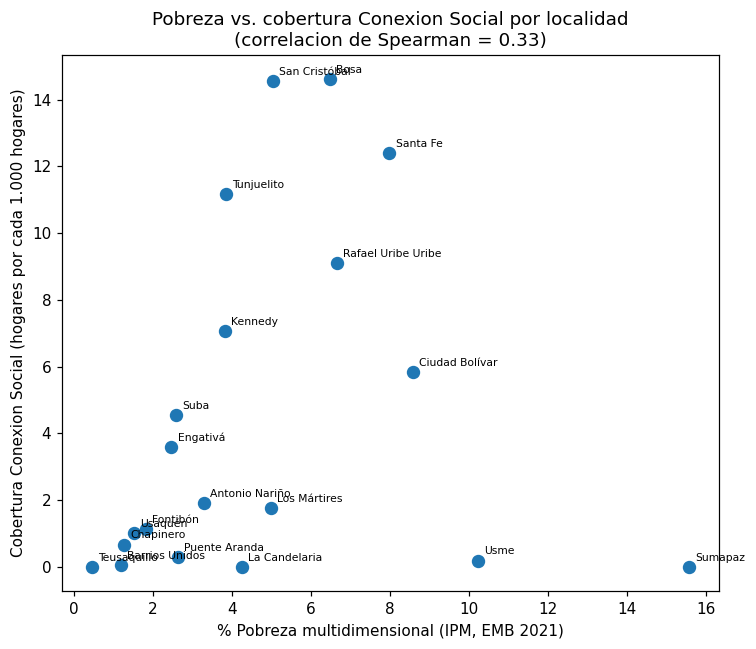

In [12]:
cruce_localidad.drop(columns="LOC_KEY").to_csv(
    OUT_TABLES / "cruce_localidad_pobreza_conexion_social.csv", index=False
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cruce_localidad["pct_pobreza_ipm"], cruce_localidad["cobertura_cs_por_1000_hogares"], s=60)
for _, row in cruce_localidad.iterrows():
    ax.annotate(row["NOMBRE_LOCALIDAD"], (row["pct_pobreza_ipm"], row["cobertura_cs_por_1000_hogares"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("% Pobreza multidimensional (IPM, EMB 2021)")
ax.set_ylabel("Cobertura Conexion Social (hogares por cada 1.000 hogares)")
ax.set_title(f"Pobreza vs. cobertura Conexion Social por localidad\n(correlacion de Spearman = {corr:.2f})")
fig.tight_layout()
fig.savefig(OUT_FIGS / "dispersion_pobreza_vs_cobertura_localidad.png", dpi=150)
plt.show()


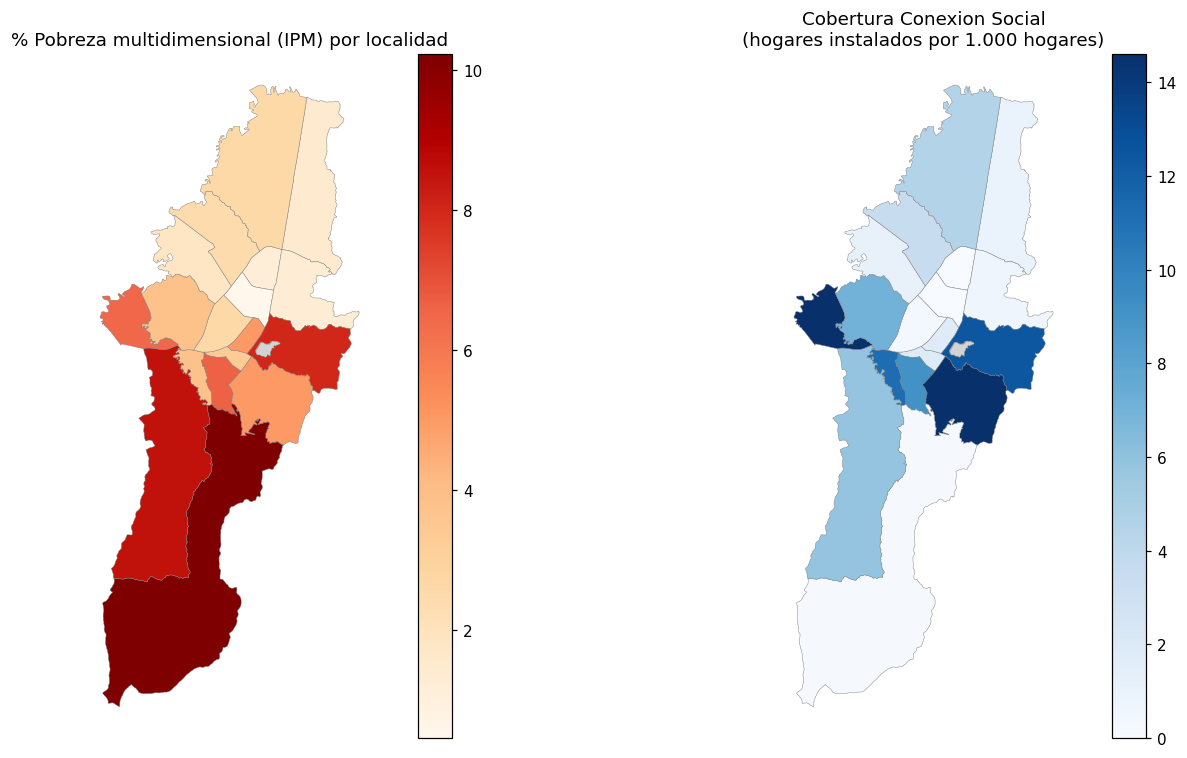

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

mapa_localidad = gdf_localidad_urbano.merge(cruce_localidad, on="LOC_KEY", how="left")

mapa_localidad.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=axes[0],
              edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
axes[0].set_title("% Pobreza multidimensional (IPM) por localidad")
axes[0].axis("off")

mapa_localidad.plot(column="cobertura_cs_por_1000_hogares", cmap="Blues", legend=True, ax=axes[1],
              edgecolor="grey", linewidth=0.3, missing_kwds={"color": "lightgrey"})
axes[1].set_title("Cobertura Conexion Social\n(hogares instalados por 1.000 hogares)")
axes[1].axis("off")

fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_pobreza_vs_cobertura_localidad.png", dpi=150)
plt.show()


### 6.1 Cruce a nivel de UPZ (grupo EMB)

In [14]:
cs_por_grupo_upz = df_cs.groupby("NOMBRE_UPZ_GRUPO").size().rename("hogares_cs").reset_index()

cruce_upz = ipm_upz.merge(cs_por_grupo_upz, on="NOMBRE_UPZ_GRUPO", how="left")
cruce_upz["hogares_cs"] = cruce_upz["hogares_cs"].fillna(0)
cruce_upz["cobertura_cs_por_1000_hogares"] = (
    cruce_upz["hogares_cs"] / cruce_upz["hogares_totales_estimados_emb"] * 1000
)
cruce_upz = cruce_upz.sort_values("pct_pobreza_ipm", ascending=False)
cruce_upz.to_csv(OUT_TABLES / "cruce_upz_pobreza_conexion_social.csv", index=False)

corr_upz = cruce_upz[["pct_pobreza_ipm", "cobertura_cs_por_1000_hogares"]].corr(method="spearman").iloc[0, 1]
print(f"Correlacion de Spearman (pobreza IPM vs. cobertura CS) por grupo de UPZ: {corr_upz:.2f}")
cruce_upz.head(15)


Correlacion de Spearman (pobreza IPM vs. cobertura CS) por grupo de UPZ: 0.57


,NOMBRE_UPZ_GRUPO,pct_pobreza_ipm,hogares_totales_estimados_emb,hogares_cs,cobertura_cs_por_1000_hogares
88,USME: Alfonso López + Ciudad Usme,16.510320,25148.782425,0.0,0.000000
42,La Flora,15.266510,6762.234654,0.0,0.000000
54,Lourdes,14.072589,13755.443256,367.0,26.680347
12,CIUDAD BOLÍVAR: Monteblanco + El Tesoro + El M...,13.000301,18859.672774,37.0,1.961858
55,Lucero,10.618561,54244.144513,260.0,4.793144
89,USME: Parque Entrenubes + Danubio,10.161630,18905.434955,24.0,1.269476
72,San Isidro - Patios,10.089829,5746.487615,0.0,0.000000
22,Diana Turbay,9.707758,26469.746768,323.0,12.202610
56,Marco Fidel Suárez,9.461298,18328.179787,420.0,22.915533
63,Patio Bonito,9.438808,45151.630743,888.0,19.667064


### 6.2 Mapa combinado: intensidad de IPM + ubicacion de los hogares CS

Un unico mapa con la intensidad de pobreza multidimensional (relleno de color por
localidad) y, encima, un punto por cada hogar instalado de Conexion Social.

> **Nota de privacidad:** a diferencia de las demas figuras de este notebook, este
> mapa grafica la **coordenada exacta de cada uno de los 15.465 hogares**. Se genera y
> se sube por decision explicita del equipo. Si en algun momento este mapa va a
> circular fuera del equipo (jurados externos, publicaciones, etc.), es preferible
> usar una version de densidad (hexbin/mapa de calor) en vez de puntos exactos, para
> no exponer la ubicacion precisa de hogares vulnerables.


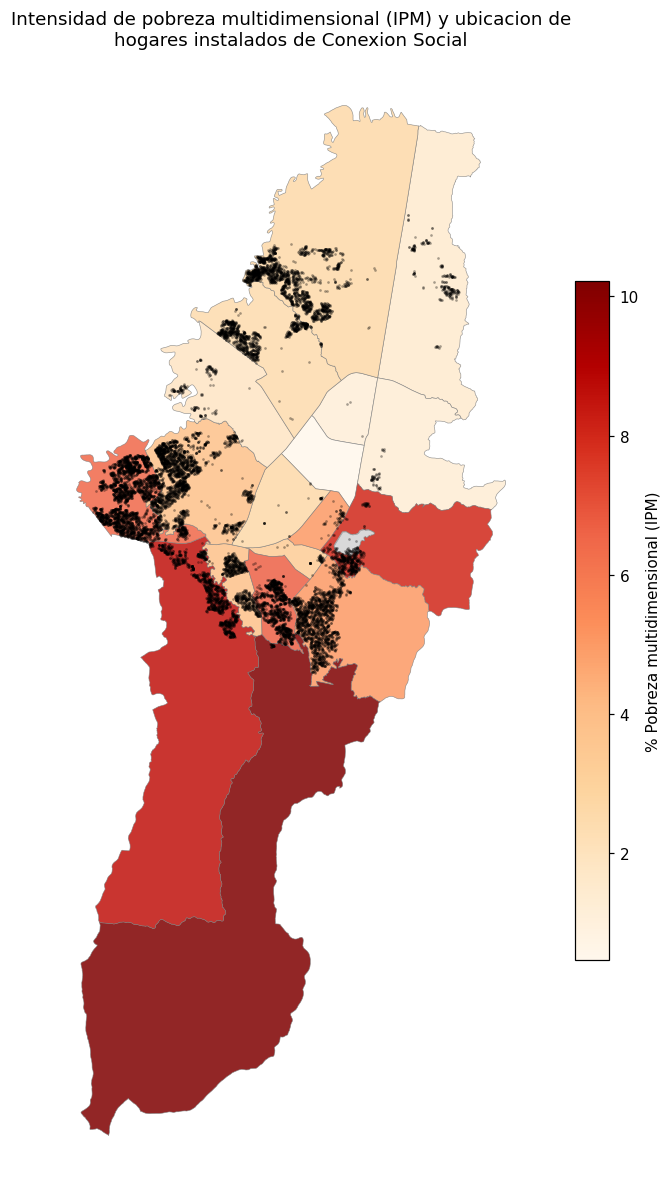

In [15]:
fig, ax = plt.subplots(figsize=(9, 11))

mapa_localidad.plot(column="pct_pobreza_ipm", cmap="OrRd", legend=True, ax=ax,
                     edgecolor="grey", linewidth=0.4, alpha=0.85,
                     missing_kwds={"color": "lightgrey"},
                     legend_kwds={"label": "% Pobreza multidimensional (IPM)", "shrink": 0.6})

gdf_cs.plot(ax=ax, markersize=3, color="black", alpha=0.35, linewidth=0)

ax.set_title("Intensidad de pobreza multidimensional (IPM) y ubicacion de\nhogares instalados de Conexion Social")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_ipm_con_hogares_cs.png", dpi=150)
plt.show()


## 7. Distribucion por sector catastral (solo descriptiva)

**Limitacion estadistica:** la EMB 2021 esta diseñada para ser representativa a nivel
de localidad y, con mayor margen de error, a nivel de grupo de UPZ. **No tiene tamaño
de muestra suficiente para estimar el IPM de forma confiable a nivel de sector
catastral** (unidades mucho mas pequeñas que una UPZ). Por eso esta seccion solo
muestra donde se concentran las instalaciones de Conexion Social a ese nivel de
detalle, sin cruzarlo contra pobreza. Esto confirma el hallazgo de la nota tecnica del
equipo: los datos publicos disponibles no permiten un analisis de focalizacion
intra-local con la misma fuente de pobreza.


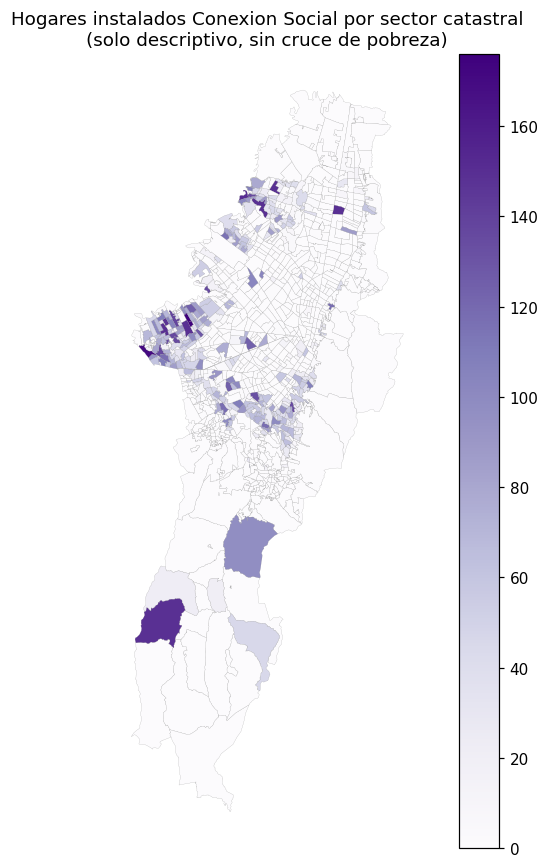

In [16]:
cs_sector_geo = gdf_sector.merge(cs_sector, left_on="SCANOMBRE", right_on="SCaNombre", how="left")
cs_sector_geo["hogares_cs"] = cs_sector_geo["hogares_cs"].fillna(0)
cs_sector_geo.to_file(GEO_DIR / "sector_catastral_hogares_cs.geojson", driver="GeoJSON")

cs_sector.sort_values("hogares_cs", ascending=False).to_csv(
    OUT_TABLES / "hogares_cs_por_sector_catastral.csv", index=False
)

# Para el mapa se recorta a la extension urbana (ver nota cartografica de la seccion 2)
cs_sector_geo_urbano = cs_sector_geo[cs_sector_geo.intersects(area_urbana_union)]

fig, ax = plt.subplots(figsize=(8, 8))
cs_sector_geo_urbano.plot(column="hogares_cs", cmap="Purples", legend=True, ax=ax,
                    edgecolor="grey", linewidth=0.1)
ax.set_title("Hogares instalados Conexion Social por sector catastral\n(solo descriptivo, sin cruce de pobreza)")
ax.axis("off")
fig.tight_layout()
fig.savefig(OUT_FIGS / "mapa_hogares_cs_sector_catastral.png", dpi=150)
plt.show()


## 8. Pendiente: cruce con SIMAT (matricula por establecimiento educativo)

Esta seccion se deja preparada para cuando el equipo disponga del archivo de SIMAT
(numero de estudiantes matriculados por establecimiento educativo oficial). Durante la
exploracion de datos abiertos se identifico un dataset publico que cumple ese
proposito -- **"Matricula Total en Colegios Oficiales. Bogota D.C."**, con corte a
SIMAT 30/04/2025, columna `TMATRIC_GE` (total matriculados) y `COD_LOCA` por colegio --
pero su incorporacion se pauso a peticion del equipo. Para activarlo:

1. Ubicar el archivo de SIMAT (propio o el dataset publico mencionado) en
   `DataJam/` (se ignora en git igual que las demas fuentes sensibles).
2. Cargarlo como GeoDataFrame de puntos (si trae coordenadas) o como tabla por
   colegio/localidad/UPZ.
3. Agregar el numero de estudiantes por localidad/UPZ/sector catastral con la misma
   logica de las secciones 5 y 6, y cruzarlo contra `cs_localidad`, `cs_upz` y
   `cs_sector`.


In [17]:
# --- Placeholder: descomentar y ajustar cuando se disponga del archivo SIMAT ---

# ruta_simat = DATA_DIR / "simat.csv"  # o .xlsx / .geojson segun el formato disponible
# df_simat = pd.read_csv(ruta_simat)
# estudiantes_localidad = df_simat.groupby("NOMBRE_LOCALIDAD")["N_ESTUDIANTES"].sum()
# cruce_localidad_simat = cruce_localidad.merge(estudiantes_localidad, ...)
print("Seccion pendiente de activar cuando se disponga del archivo SIMAT.")


Seccion pendiente de activar cuando se disponga del archivo SIMAT.


## 9. Base de datos agregada para Power BI

Se arma una pequeña "base de datos" (5 tablas, todas agregadas por geografia -
**ningun hogar individual**) lista para conectar en Power BI Desktop, en dos formatos:

- `outputs/powerbi/bd_conexion_social_powerbi.xlsx` - un libro de Excel con una hoja
  por tabla. Es la forma mas simple: en Power BI, *Obtener datos* > *Excel* > seleccionar
  el archivo > marcar las 5 hojas.
- `outputs/powerbi/bd_conexion_social_powerbi.db` - la misma informacion en SQLite. En
  Power BI: *Obtener datos* > *Base de datos SQLite* (requiere el driver ODBC de
  SQLite instalado una sola vez; si no lo tienes, usa el Excel).

### Tablas

| Tabla | Contenido | Grano |
|---|---|---|
| `dim_localidad` | % IPM, hogares totales EMB, hogares CS, cobertura por 1.000 | 1 fila por localidad |
| `dim_upz` | Igual que la anterior, a nivel de grupo de UPZ | 1 fila por grupo UPZ |
| `dim_sector_catastral` | Hogares CS instalados | 1 fila por sector catastral |
| `hogares_cs_por_estrato` | Conteo de hogares CS | 1 fila por localidad x estrato |
| `hogares_cs_por_clasificacion_sisben` | Conteo de hogares CS | 1 fila por localidad x clasificacion Sisben |


In [18]:
import sqlite3

POWERBI_DIR = BASE_DIR / "outputs" / "powerbi"
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

dim_localidad = cruce_localidad.drop(columns="LOC_KEY").rename(columns={"NOMBRE_LOCALIDAD": "localidad"})
dim_upz = cruce_upz.rename(columns={"NOMBRE_UPZ_GRUPO": "upz_grupo"})
dim_sector_catastral = cs_sector.rename(columns={"SCaNombre": "sector_catastral"})

hogares_cs_por_estrato = (
    gdf_cs.groupby(["LOCNOMBRE", "ESTRATO"]).size().rename("hogares_cs").reset_index()
    .rename(columns={"LOCNOMBRE": "localidad"})
)
hogares_cs_por_clasificacion_sisben = (
    gdf_cs.groupby(["LOCNOMBRE", "CLASIFICACION_DIC"]).size().rename("hogares_cs").reset_index()
    .rename(columns={"LOCNOMBRE": "localidad", "CLASIFICACION_DIC": "clasificacion_sisben"})
)

tablas_powerbi = {
    "dim_localidad": dim_localidad,
    "dim_upz": dim_upz,
    "dim_sector_catastral": dim_sector_catastral,
    "hogares_cs_por_estrato": hogares_cs_por_estrato,
    "hogares_cs_por_clasificacion_sisben": hogares_cs_por_clasificacion_sisben,
}

with pd.ExcelWriter(POWERBI_DIR / "bd_conexion_social_powerbi.xlsx", engine="openpyxl") as writer:
    for nombre, tabla in tablas_powerbi.items():
        tabla.to_excel(writer, sheet_name=nombre[:31], index=False)

db_path = POWERBI_DIR / "bd_conexion_social_powerbi.db"
db_path.unlink(missing_ok=True)
with sqlite3.connect(db_path) as con:
    for nombre, tabla in tablas_powerbi.items():
        tabla.to_sql(nombre, con, index=False)

for nombre, tabla in tablas_powerbi.items():
    print(f"{nombre}: {tabla.shape[0]} filas x {tabla.shape[1]} columnas")


dim_localidad: 20 filas x 5 columnas
dim_upz: 95 filas x 5 columnas
dim_sector_catastral: 448 filas x 2 columnas
hogares_cs_por_estrato: 36 filas x 3 columnas
hogares_cs_por_clasificacion_sisben: 324 filas x 3 columnas


### 9.1 Ejemplo de tablero sugerido (para armar en Power BI Desktop)

Este notebook prepara los **datos**; el archivo `.pbix` en si se arma en Power BI
Desktop (formato propietario que no se puede generar por codigo). Estructura sugerida
para un tablero de una pagina:

1. **Tarjetas KPI arriba:** total hogares instalados (`SUM(dim_localidad[hogares_cs])`),
   meta del programa (100.000, dato fijo del formulario), % de avance.
2. **Mapa central:** visual *Mapa de formas* (Shape Map) o *ArcGIS Maps for Power BI*
   usando `data/geo/localidad.geojson` como capa de referencia, coloreado por
   `dim_localidad[pct_pobreza_ipm]`. Alternativa mas simple sin geojson: visual
   *Mapa* (burbujas) con el campo `localidad` (Power BI geocodifica el nombre) y
   tamaño de burbuja = `hogares_cs`.
3. **Barras a la derecha:** `dim_localidad` ordenado por `cobertura_cs_por_1000_hogares`,
   para ver rapidamente que localidades tienen alta pobreza y baja cobertura (el
   hallazgo de la seccion 6).
4. **Filtro/segmentador:** por `localidad`, que afecte tanto el mapa como las tablas
   de `hogares_cs_por_estrato` y `hogares_cs_por_clasificacion_sisben` (perfil
   socioeconomico de los hogares instalados en la localidad seleccionada).
5. **Relaciones del modelo:** en la vista de *Modelado* de Power BI, relaciona
   `dim_localidad[localidad]` con `hogares_cs_por_estrato[localidad]` y con
   `hogares_cs_por_clasificacion_sisben[localidad]` (cardinalidad 1 a muchos).


## 10. Resumen de resultados exportados

Todos los resultados **agregados** (sin datos individuales, salvo el mapa de la
seccion 6.2 que se documenta aparte) quedan en:

- `outputs/tables/cruce_localidad_pobreza_conexion_social.csv`
- `outputs/tables/cruce_upz_pobreza_conexion_social.csv`
- `outputs/tables/hogares_cs_por_sector_catastral.csv`
- `outputs/figures/dispersion_pobreza_vs_cobertura_localidad.png`
- `outputs/figures/mapa_pobreza_vs_cobertura_localidad.png`
- `outputs/figures/mapa_ipm_con_hogares_cs.png` (contiene coordenadas exactas de hogares, ver nota 6.2)
- `outputs/figures/mapa_hogares_cs_sector_catastral.png`
- `outputs/powerbi/bd_conexion_social_powerbi.xlsx` y `.db` (base de datos para Power BI)
- `data/geo/*.geojson` (limites publicos de localidad, UPZ y sector catastral)

Los microdatos originales (`Perfiles_CS.xlsx`, `em2021.csv`,
`20240430_variables_adicionales_2021.csv`) permanecen solo en este computador.


In [19]:
resumen = pd.DataFrame({
    "archivo": [
        "cruce_localidad_pobreza_conexion_social.csv",
        "cruce_upz_pobreza_conexion_social.csv",
        "hogares_cs_por_sector_catastral.csv",
        "bd_conexion_social_powerbi.xlsx (5 hojas)",
    ],
    "filas": [len(cruce_localidad), len(cruce_upz), len(cs_sector), sum(len(t) for t in tablas_powerbi.values())],
})
resumen


,archivo,filas
0,cruce_localidad_pobreza_conexion_social.csv,20
1,cruce_upz_pobreza_conexion_social.csv,95
2,hogares_cs_por_sector_catastral.csv,448
3,bd_conexion_social_powerbi.xlsx (5 hojas),923
